In [1]:
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
import imageio.v3 as iio
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from core.data import CompressionMetrics
from core.utils import make_dual_update, round_sig
from core.image3d import reconstruct_image3d, compress_image3d

In [12]:
image3d_raw = iio.imread("../sources/drosophila_1slice.y4m")
image3d_raw = image3d_raw[:, :, :, 0]
nt, nx, ny = 30, 30, 30
image3d = image3d_raw[:nt, :nx, :ny]
# plt.imshow(image3d[0], cmap="gray")
# plt.show()

In [13]:
# Hyperparameters
poly_degree = 6
lp_degree = 1.0
block_size = 10
cutoff = None

In [14]:
c, X_design, rescale = compress_image3d(
    image3d, poly_degree, block_size, lp_degree, p_inv=True, cutoff=cutoff
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  18 out of  27 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  24 out of  27 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  27 out of  27 | elapsed:    0.0s finished


In [15]:
c = round_sig(c)
image3d_rec = reconstruct_image3d(c, X_design, rescale)

In [16]:
# Saving coefficients
np.save("../results/image3d/drosophila_1slice/coefficients__bs=%s__cutoff=%s__lp=%s__poly_deg=%s__dtype=%s.npy" %
(block_size, cutoff, lp_degree, poly_degree, c.dtype), c, allow_pickle=False)

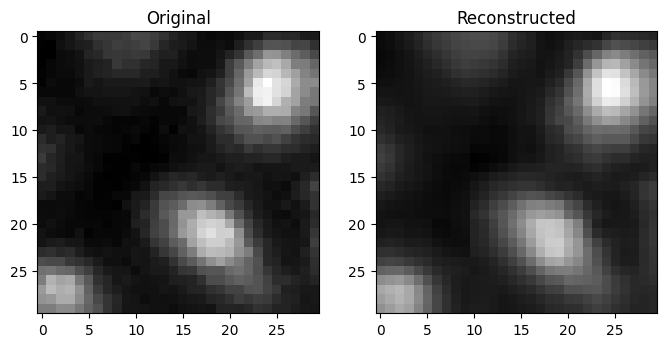

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(8,4))

im_orig = ax[0].imshow(image3d[0], cmap='gray')
ax[0].set_title("Original")

im_rec = ax[1].imshow(image3d_rec[0], cmap='gray')
ax[1].set_title("Reconstructed")

update = make_dual_update(image3d, image3d_rec, im_orig, im_rec)
ani = animation.FuncAnimation(fig, update, frames=len(image3d), interval=200, blit=True)

In [18]:
from IPython.display import HTML
HTML(ani.to_jshtml())

In [21]:
metrics = CompressionMetrics(image3d, image3d_rec, c) 

In [22]:
import pandas as pd
metrics_dict = {
    "Metric": ["Nonzero Coefficients (%)", "MSE", "PSNR (dB)", "Compression Ratio (%)", "Space Saved (%)", "SSIM"],
    "Value": [metrics.nz_percent, metrics.mse, metrics.psnr, metrics.compression_ratio, metrics.space_saved, metrics.ssim]
}
df = pd.DataFrame(metrics_dict)
print(df)

                     Metric       Value
0  Nonzero Coefficients (%)  100.000000
1                       MSE   51.436387
2                 PSNR (dB)   31.018099
3     Compression Ratio (%)    8.400000
4           Space Saved (%)   91.600000
5                      SSIM    0.961768
